In [2]:
import numpy as np
import math 
import matplotlib.pyplot as plt

### True Underlying Environment

In [3]:
def set_environment(n, arms, mu_a, tau_a, sigma_a, T, env_seed=0):
    mu_a = np.asarray(mu_a, dtype=float)
    tau_a = np.asarray(tau_a, dtype=float)
    sigma_a = np.asarray(sigma_a, dtype=float)

    env_rng = np.random.default_rng(env_seed)
    theta = env_rng.normal(loc=mu_a, scale=tau_a, size=(n, arms))

    return theta, sigma_a

### Learning Algorithms

#### Pooled epsilon greedy algorithm — Betina

In [4]:
def pooled_epsilon_greedy(times, participants, n_arms, theta, sigma_arm, rng, eps=0.1):
    sigma_arm = np.asarray(sigma_arm, dtype=float)

    Q_new = np.zeros(n_arms, dtype=float)
    N_new = np.zeros(n_arms, dtype=int)

    actions_new = np.zeros((participants, times), dtype=int)
    rewards_new = np.zeros((participants, times), dtype=float)

    for t in range(times):
        if rng.random() < eps:
            a = int(rng.integers(0, n_arms))
        else:
            best = np.flatnonzero(Q_new == Q_new.max())
            a = int(rng.choice(best))

        r = rng.normal(loc=theta[:, a], scale=sigma_arm[a], size=participants)

        actions_new[:, t] = a
        rewards_new[:, t] = r

        N_new[a] += participants
        Q_new[a] += (r.mean() - Q_new[a]) * (participants / N_new[a])

    return Q_new, N_new, actions_new, rewards_new

#### Thompson Sampling (Unpooled) — Betina

- keeps posterior distribution over each arm's true mean
- samples over arms from the posteriror and chooses arm with highest sampled value
- updates posterior using the reward observed

- note this loops through people one at a time 

In [5]:
def thompson_sampling(times, participants, n_arms, theta, sigma_r, rng, mu0, tau0):
    sigma_r = np.asarray(sigma_r, dtype=float)  # allow scalar or per-arm SD
    mu0  = np.asarray(mu0, dtype=float)         # MUST be length n_arms
    tau0 = np.asarray(tau0, dtype=float)        # MUST be length n_arms (SD)

    # number of times person i tried arm a
    N = np.zeros((participants, n_arms), dtype=int)

    # sum of rewards for specific arm
    S = np.zeros((participants, n_arms), dtype=float)

    actions = np.full((participants, times), -1, dtype=int)
    rewards = np.zeros((participants, times), dtype=float)

    for t in range(times):
        for i in range(participants):
            post_mean = np.zeros(n_arms, dtype=float)
            post_var  = np.ones(n_arms, dtype=float)

            for a in range(n_arms):
                mu0_a  = float(mu0[a])
                tau0_a = float(tau0[a])

                if N[i, a] == 0:
                    # No data yet. posterior = prior
                    post_mean[a] = mu0_a
                    post_var[a]  = tau0_a**2
                else:
                    # have data so do normal-normal conjugacy to update
                    sig2 = float(sigma_r)**2 if sigma_r.size == 1 else float(sigma_r[a])**2

                    precision_data  = N[i, a] / sig2
                    precision_prior = 1.0 / (tau0_a**2)

                    post_var[a]  = 1.0 / (precision_data + precision_prior)
                    post_mean[a] = post_var[a] * (mu0_a/(tau0_a**2) + S[i, a]/sig2)

            # Thompson step: sample a plausible true mean for each arm
            sampled = rng.normal(loc=post_mean, scale=np.sqrt(post_var))

            # choose arm that is best
            a_star = int(np.argmax(sampled))

            # reward for this participant on chosen arm
            sig = float(sigma_r) if sigma_r.size == 1 else float(sigma_r[a_star])
            r = rng.normal(loc=theta[i, a_star], scale=sig)

            actions[i, t] = a_star
            rewards[i, t] = r

            N[i, a_star] += 1
            S[i, a_star] += r

    return N, S, actions, rewards

#### Thompson Sampling (Pooled) — Betina

In [6]:
def pooled_thompson_sampling(times, participants, n_arms, theta, sigma_r, rng, mu0, tau0):
    sigma_r = np.asarray(sigma_r, dtype=float)  # allow scalar or per-arm SD
    mu0  = np.asarray(mu0, dtype=float)         # MUST be length n_arms
    tau0 = np.asarray(tau0, dtype=float)        # MUST be length n_arms (SD)

    N = np.zeros(n_arms, dtype=int)     # POOLED per arm
    S = np.zeros(n_arms, dtype=float)   # pooled sum of rewards per arm

    actions = np.full((participants, times), -1, dtype=int)
    rewards = np.zeros((participants, times), dtype=float)

    for t in range(times):
        post_mean = np.zeros(n_arms, dtype=float)
        post_var  = np.ones(n_arms, dtype=float)

        for a in range(n_arms):
            mu0_a  = float(mu0[a])
            tau0_a = float(tau0[a])

            if N[a] == 0:
                # No data yet. posterior = prior
                post_mean[a] = mu0_a
                post_var[a]  = tau0_a**2
            else:
                sig2 = float(sigma_r)**2 if sigma_r.size == 1 else float(sigma_r[a])**2

                precision_data  = N[a] / sig2
                precision_prior = 1.0 / (tau0_a**2)

                post_var[a]  = 1.0 / (precision_data + precision_prior)
                post_mean[a] = post_var[a] * (mu0_a/(tau0_a**2) + S[a]/sig2)

        # Thompson step: sample a plausible true mean for each arm
        sampled = rng.normal(loc=post_mean, scale=np.sqrt(post_var))

        # choose arm that is best
        a_star = int(np.argmax(sampled))

        sig = float(sigma_r) if sigma_r.size == 1 else float(sigma_r[a_star])
        r = rng.normal(loc=theta[:, a_star], scale=sig, size=participants)

        actions[:, t] = a_star
        rewards[:, t] = r

        N[a_star] += participants
        S[a_star] += r.sum()

    return N, S, actions, rewards

#### Empirical Bayes — Nora

Empirical Bayes
1. Simple Bayesian learning algorithm
2. Empirical Bayes decision-making

In [7]:
def learning_empirical_bayes(times, participants, n_arms, theta, sigma_arm, rng, mu0, tau0):
    sigma_arm = np.asarray(sigma_arm, dtype=float)  # allow scalar or per-arm SD
    mu0  = np.asarray(mu0, dtype=float)             # MUST be length n_arms
    tau0 = np.asarray(tau0, dtype=float)            # MUST be length n_arms (SD)

    # these are our priors (vector priors)
    m = np.tile(mu0, (participants, 1))
    v = np.tile(tau0**2, (participants, 1))

    N = np.zeros((participants, n_arms), dtype=int)
    actions = np.zeros((participants, times), dtype=int)
    rewards = np.zeros((participants, times), dtype=float)

    def normal_cdf(z):
        return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

    def profile_ll_and_mu(x, s2, tau2):
        w = 1.0 / (s2 + tau2)
        mu = np.sum(w * x) / np.sum(w)
        ll = -0.5 * np.sum(np.log(s2 + tau2) + (x - mu) ** 2 * w)
        return ll, mu

    def fit_mu_tau2(x, s2):
        x = np.asarray(x, dtype=float)
        s2 = np.asarray(s2, dtype=float)

        base = float(np.var(x)) + float(np.mean(s2))
        hi = max(1e-6, 10.0 * base)
        grid = np.logspace(-8, np.log10(hi), 120)

        best_tau2 = 0.0
        best_ll, best_mu = profile_ll_and_mu(x, s2, 0.0)

        for tau2 in grid:
            ll, mu = profile_ll_and_mu(x, s2, float(tau2))
            if ll > best_ll:
                best_ll, best_mu, best_tau2 = ll, mu, float(tau2)

        return best_mu, best_tau2

    for t in range(times):
        mu_hat = np.zeros(n_arms, dtype=float)
        tau2_hat = np.zeros(n_arms, dtype=float)

        for a in range(n_arms):
            mu_hat[a], tau2_hat[a] = fit_mu_tau2(m[:, a], v[:, a])

        m_eb = np.zeros_like(m, dtype=float)
        v_eb = np.zeros_like(v, dtype=float)

        for a in range(n_arms):
            if tau2_hat[a] <= 0.0:
                m_eb[:, a] = mu_hat[a]
                v_eb[:, a] = 0.0
            else:
                lam = tau2_hat[a] / (tau2_hat[a] + v[:, a])
                m_eb[:, a] = lam * m[:, a] + (1.0 - lam) * mu_hat[a]
                v_eb[:, a] = 1.0 / (1.0 / v[:, a] + 1.0 / tau2_hat[a])

        for i in range(participants):
            if n_arms == 2:
                m_diff = m_eb[i, 1] - m_eb[i, 0]
                v_diff = v_eb[i, 1] + v_eb[i, 0]
                if v_diff <= 0.0:
                    a = 1 if m_diff > 0.0 else 0
                else:
                    p1 = normal_cdf(m_diff / math.sqrt(v_diff))
                    a = 1 if rng.random() < p1 else 0
            else:
                sample = rng.normal(loc=m_eb[i], scale=np.sqrt(np.maximum(v_eb[i], 0.0)))
                a = int(np.argmax(sample))

            # reward
            r = rng.normal(loc=theta[i, a], scale=sigma_arm[a])

            actions[i, t] = a
            rewards[i, t] = r
            N[i, a] += 1

            # update per-person posterior for chosen arm
            sig2 = float(sigma_arm[a]) ** 2
            prec = 1.0 / v[i, a] + 1.0 / sig2
            v_new = 1.0 / prec
            m_new = v_new * (m[i, a] / v[i, a] + r / sig2)

            m[i, a] = m_new
            v[i, a] = v_new

    return m, v, N, actions, rewards

### Simulations

#### Functions

In [8]:
def cumulative_regret(theta, actions):
    n, T = actions.shape
    best = theta.max(axis=1, keepdims=True)
    chosen = theta[np.arange(n)[:, None], actions]
    inst = best - chosen
    return np.cumsum(inst.mean(axis=0))

def evaluate(theta, sigma_a, T, eps, mu0, tau0, seed=123):
    n, arms = theta.shape
    mu0  = np.asarray(mu0, dtype=float)
    tau0 = np.asarray(tau0, dtype=float)

    rng_pool_eps = np.random.default_rng(seed + 1)
    rng_ts       = np.random.default_rng(seed + 2)
    rng_pool_ts  = np.random.default_rng(seed + 3)
    rng_eb       = np.random.default_rng(seed + 4)

    Q_p, N_p, actions_p, rewards_p = pooled_epsilon_greedy(
        T, n, arms, theta, sigma_a, rng_pool_eps, eps=eps
    )

    N_ts, S_ts, actions_ts, rewards_ts = thompson_sampling(
        T, n, arms, theta, sigma_a, rng_ts, mu0=mu0, tau0=tau0
    )

    N_pts, S_pts, actions_pts, rewards_pts = pooled_thompson_sampling(
        T, n, arms, theta, sigma_a, rng_pool_ts, mu0=mu0, tau0=tau0
    )

    m_eb, v_eb, N_eb, actions_eb, rewards_eb = learning_empirical_bayes(
        T, n, arms, theta, sigma_a, rng_eb, mu0=mu0, tau0=tau0
    )

    return {
        "actions_pooled_eps": actions_p,
        "actions_thompson": actions_ts,
        "actions_pooled_thompson": actions_pts,
        "actions_eb": actions_eb,
        "regret_pooled_eps": cumulative_regret(theta, actions_p),
        "regret_thompson": cumulative_regret(theta, actions_ts),
        "regret_pooled_thompson": cumulative_regret(theta, actions_pts),
        "regret_eb": cumulative_regret(theta, actions_eb),
        "rewards_pooled_eps": rewards_p,
        "rewards_thompson": rewards_ts,
        "rewards_pooled_thompson": rewards_pts,
        "rewards_eb": rewards_eb,
        "N_ts": N_ts,
        "S_ts": S_ts,
        "N_pooled_ts": N_pts,
        "S_pooled_ts": S_pts,
        "m_eb": m_eb,
        "v_eb": v_eb,
        "N_eb": N_eb,
    }

In [16]:
def plot(ns, mus, taus, T, sigma_a, n_runs=50, env_seed=0, eps=0.1,
         mu0=None, tau0=None, show_prior_in_title=True, note=None):
    PASTEL = {
        "pooled_eps": "#A1C9F4",
        "thompson": "#FFB482",
        "pooled_thompson": "#9C88B9",
        "eb": "#8DE5A1",
    }

    def fmt_vec(x):
        x = np.asarray(x, dtype=float)
        return "[" + ", ".join(f"{v:.2f}" for v in x) + "]"

    n_rows = len(taus)
    n_cols = len(mus)

    for n_val in ns:
        fig, axs = plt.subplots(
            n_rows, n_cols,
            figsize=(3.2 * n_cols, 2.4 * n_rows),
            sharex=True, sharey=True
        )

        if n_rows == 1 and n_cols == 1:
            axs = np.array([[axs]])
        elif n_rows == 1:
            axs = np.array([axs])
        elif n_cols == 1:
            axs = np.array([[ax] for ax in axs])

        for i, tau_val in enumerate(taus):
            for j, mu_val in enumerate(mus):
                mu_env  = [0.0, float(mu_val)]
                tau_env = [float(tau_val), float(tau_val)]

                theta, sigma_env = set_environment(
                    n=n_val, arms=2, mu_a=mu_env, tau_a=tau_env,
                    sigma_a=sigma_a, T=T, env_seed=env_seed
                )

                # Priors for this panel:
                # - if mu0/tau0 are callables, compute from env
                # - else they must be fixed vectors length 2
                if callable(mu0):
                    mu0_use = np.asarray(mu0(mu_env, tau_env), dtype=float)
                else:
                    mu0_use = np.asarray(mu0, dtype=float)

                if callable(tau0):
                    tau0_use = np.asarray(tau0(mu_env, tau_env), dtype=float)
                else:
                    tau0_use = np.asarray(tau0, dtype=float)

                reg_pe_list  = []
                reg_ts_list  = []
                reg_pts_list = []
                reg_eb_list  = []

                for r in range(n_runs):
                    out = evaluate(
                        theta=theta,
                        sigma_a=sigma_env,
                        T=T,
                        eps=eps,
                        mu0=mu0_use,
                        tau0=tau0_use,
                        seed=r
                    )
                    reg_pe_list.append(out["regret_pooled_eps"])
                    reg_ts_list.append(out["regret_thompson"])
                    reg_pts_list.append(out["regret_pooled_thompson"])
                    reg_eb_list.append(out["regret_eb"])

                reg_pe  = np.mean(reg_pe_list, axis=0)
                reg_ts  = np.mean(reg_ts_list, axis=0)
                reg_pts = np.mean(reg_pts_list, axis=0)
                reg_eb  = np.mean(reg_eb_list, axis=0)

                # best alg
                final_vals = {
                    "Pooled ε-greedy": reg_pe[-1],
                    "Thompson": reg_ts[-1],
                    "Pooled Thompson": reg_pts[-1],
                    "EB": reg_eb[-1],
                }

                best_alg = min(final_vals, key=final_vals.get)

                ax = axs[i, j]
                ax.plot(reg_pe,  color=PASTEL["pooled_eps"],      linewidth=1.4)
                ax.plot(reg_ts,  color=PASTEL["thompson"],        linewidth=1.4)
                ax.plot(reg_pts, color=PASTEL["pooled_thompson"], linewidth=1.4)
                ax.plot(reg_eb,  color=PASTEL["eb"],              linewidth=1.4)

                title = f"μ₂={mu_val}, τ={tau_val}"
                title += f"\nBest: {best_alg}"
                
                ax.set_title(title, fontsize=9)

                ax.tick_params(axis="both", labelsize=7)
                if i == n_rows - 1:
                    ax.set_xlabel("t", fontsize=8)
                if j == 0:
                    ax.set_ylabel("Avg cum. regret", fontsize=8)

        handles, _ = axs[0, 0].get_legend_handles_labels()
        fig.legend(handles, ["Pooled ε-greedy", "Thompson", "Pooled Thompson", "EB"],
                   loc="upper right", fontsize=8)
        # Priors (same across panels)
        mu0_vec  = fmt_vec(mu0_use)
        tau0_vec = fmt_vec(tau0_use)
        sigma_vec = fmt_vec(sigma_a)
        
        main_title = (
            f"n = {n_val}, runs = {n_runs}\n"
            f"Within-person σ = {sigma_vec}\n"
            f"μ0 = {mu0_vec}, τ0 = {tau0_vec}"
        )
        
        if note is not None:
            main_title += f"\n{note}"
        
        fig.suptitle(main_title, fontsize=11)
        fig.tight_layout(rect=[0, 0, 0.95, 0.95])
        plt.show()

In [12]:
def plot2(ns, taus, sigmas, T, mu_env=(0.0, 0.5),
                    n_runs=50, env_seed=0, eps=0.1,
                    mu0=None, tau0=None, note=None):

    PASTEL = {
        "pooled_eps": "#A1C9F4",
        "thompson": "#FFB482",
        "pooled_thompson": "#9C88B9",
        "eb": "#8DE5A1",
    }

    def fmt_vec(x):
        x = np.asarray(x, dtype=float)
        return "[" + ", ".join(f"{v:.2f}" for v in x) + "]"

    mu_env = np.asarray(mu_env, dtype=float)

    for n_val in ns:
        # rows = taus, cols = sigmas
        n_rows = len(taus)
        n_cols = len(sigmas)

        fig, axs = plt.subplots(
            n_rows, n_cols,
            figsize=(3.2 * n_cols, 2.6 * n_rows),
            sharex=True, sharey=True
        )

        if n_rows == 1 and n_cols == 1:
            axs = np.array([[axs]])
        elif n_rows == 1:
            axs = np.array([axs])
        elif n_cols == 1:
            axs = np.array([[ax] for ax in axs])

        for i, tau_val in enumerate(taus):
            tau_env = np.asarray([float(tau_val), float(tau_val)], dtype=float)

            for j, sig_val in enumerate(sigmas):
                sigma_env = np.asarray([float(sig_val), float(sig_val)], dtype=float)

                theta, sigma_env = set_environment(
                    n=n_val, arms=2, mu_a=mu_env, tau_a=tau_env,
                    sigma_a=sigma_env, T=T, env_seed=env_seed
                )

                # priors (vector always)
                mu0_use = np.asarray(mu0, dtype=float)
                tau0_use = np.asarray(tau0, dtype=float)

                reg_pe_list, reg_ts_list, reg_pts_list, reg_eb_list = [], [], [], []

                for r in range(n_runs):
                    out = evaluate(
                        theta=theta,
                        sigma_a=sigma_env,
                        T=T,
                        eps=eps,
                        mu0=mu0_use,
                        tau0=tau0_use,
                        seed=r
                    )
                    reg_pe_list.append(out["regret_pooled_eps"])
                    reg_ts_list.append(out["regret_thompson"])
                    reg_pts_list.append(out["regret_pooled_thompson"])
                    reg_eb_list.append(out["regret_eb"])

                reg_pe  = np.mean(reg_pe_list, axis=0)
                reg_ts  = np.mean(reg_ts_list, axis=0)
                reg_pts = np.mean(reg_pts_list, axis=0)
                reg_eb  = np.mean(reg_eb_list, axis=0)

                final_vals = {
                    "Pooled ε-greedy": reg_pe[-1],
                    "Thompson": reg_ts[-1],
                    "Pooled Thompson": reg_pts[-1],
                    "EB": reg_eb[-1],
                }
                best_alg = min(final_vals, key=final_vals.get)

                ax = axs[i, j]
                ax.plot(reg_pe,  color=PASTEL["pooled_eps"],      linewidth=1.4)
                ax.plot(reg_ts,  color=PASTEL["thompson"],        linewidth=1.4)
                ax.plot(reg_pts, color=PASTEL["pooled_thompson"], linewidth=1.4)
                ax.plot(reg_eb,  color=PASTEL["eb"],              linewidth=1.4)

                ax.set_title(f"τ={tau_val}, σ={sig_val}\nBest: {best_alg}", fontsize=9)
                ax.tick_params(axis="both", labelsize=7)

                if i == n_rows - 1:
                    ax.set_xlabel("t", fontsize=8)
                if j == 0:
                    ax.set_ylabel("Avg cum. regret", fontsize=8)

        handles, _ = axs[0, 0].get_legend_handles_labels()
        fig.legend(handles,
                   ["Pooled ε-greedy", "Thompson", "Pooled Thompson", "EB"],
                   loc="upper right", fontsize=8)

        main_title = (
            f"n = {n_val} | runs = {n_runs} | T = {T}\n"
            f"env μ = {fmt_vec(mu_env)}, priors μ0 = {fmt_vec(mu0)}, τ0 = {fmt_vec(tau0)}"
        )
        if note is not None:
            main_title += f"\n{note}"

        fig.suptitle(main_title, fontsize=11)
        fig.tight_layout(rect=[0, 0, 0.95, 0.92])
        plt.show()

#### Trials - Varying Mean

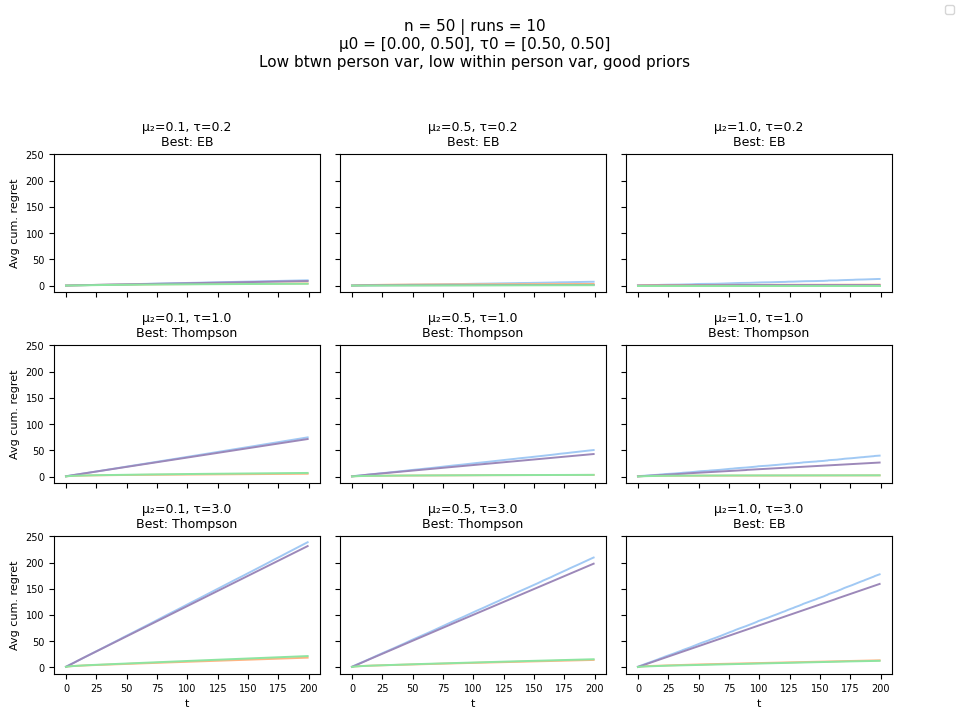

In [50]:
plot(
    ns=[50],
    mus=[0.1, 0.5, 1.0],
    taus=[0.2, 1.0, 3.0],          # baseline tau grid
    T=200,
    sigma_a=[0.5, 0.5],           # LOW within-person variance
    n_runs=10,
    env_seed=0,
    eps=0.1,
    mu0=[0.0, 0.5],               # centered in interval
    tau0=[0.5, 0.5],              # moderately informative
    note="Low btwn person var, low within person var, good priors"
)

- **Pooled** = light blue
- **Thompson** = soft orange
- **Pooled Thompson** = soft purple
- **EB** = light green

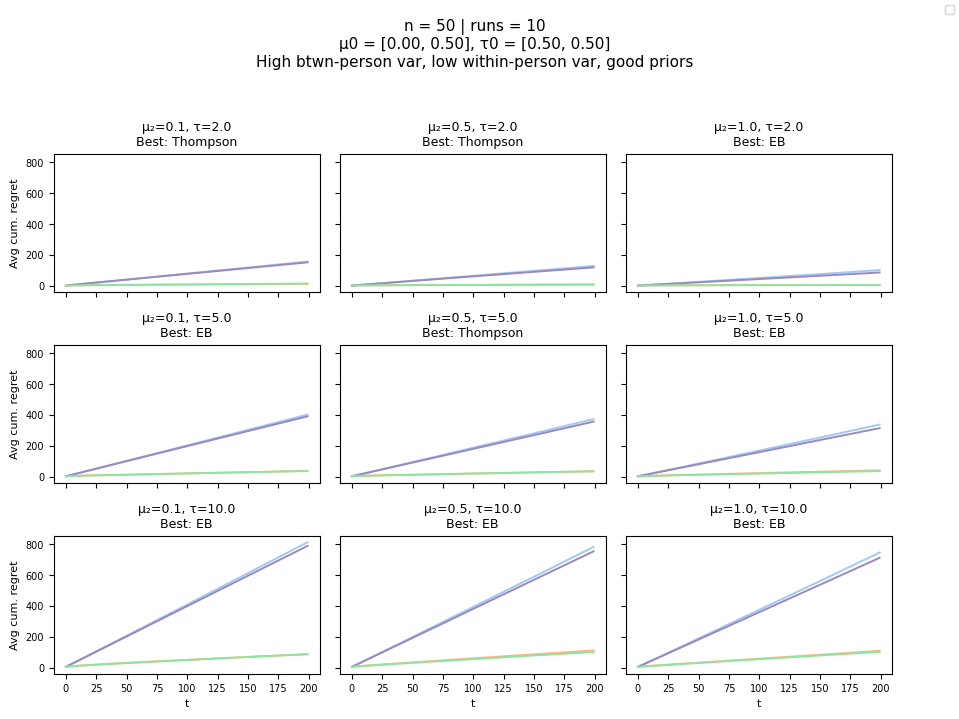

In [51]:
plot(
    ns=[50],
    mus=[0.1, 0.5, 1.0],
    taus=[2.0, 5.0, 10.0],        # HIGH between-person variance
    T=200,
    sigma_a=[0.5, 0.5],           # LOW within-person variance
    n_runs=10,
    env_seed=0,
    eps=0.1,
    mu0=[0.0, 0.5],
    tau0=[0.5, 0.5],             
    note="High btwn-person var, low within-person var, good priors"
)

- **Pooled** = light blue
- **Thompson** = soft orange
- **Pooled Thompson** = soft purple
- **EB** = light green

#### 

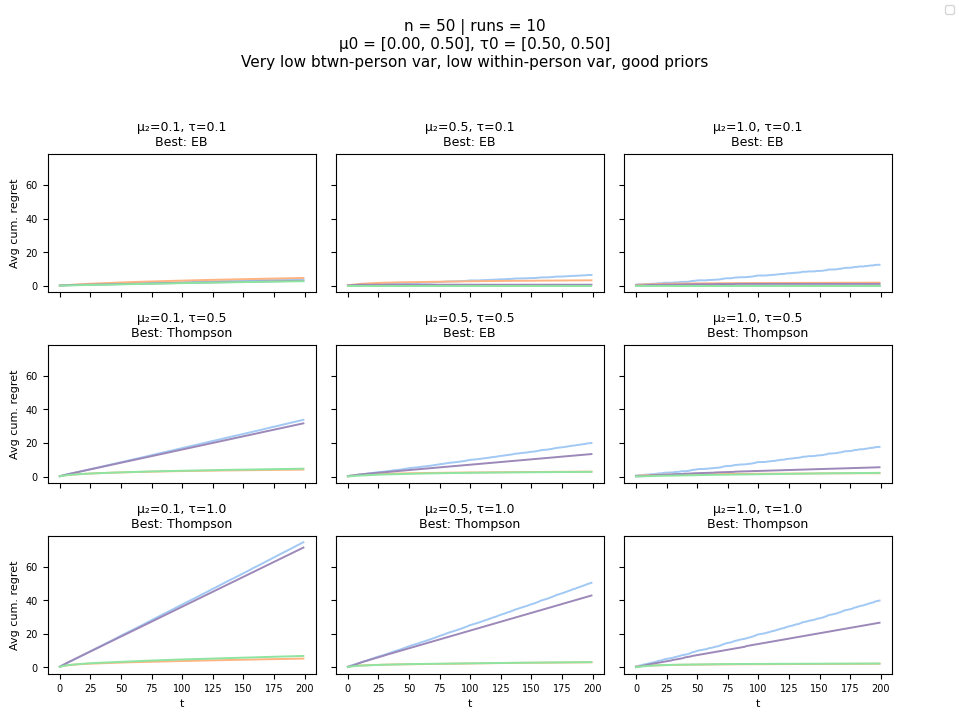

In [10]:
plot(
    ns=[50],
    mus=[0.1, 0.5, 1.0],
    taus=[0.1, 0.5, 1.0],      
    T=200,
    sigma_a=[0.5, 0.5],     
    n_runs=10,
    env_seed=0,
    eps=0.1,
    mu0=[0.0, 0.5],
    tau0=[0.5, 0.5],
    note="Very low btwn-person var, low within-person var, good priors"
)

- **Pooled** = light blue
- **Thompson** = soft orange
- **Pooled Thompson** = soft purple
- **EB** = light green

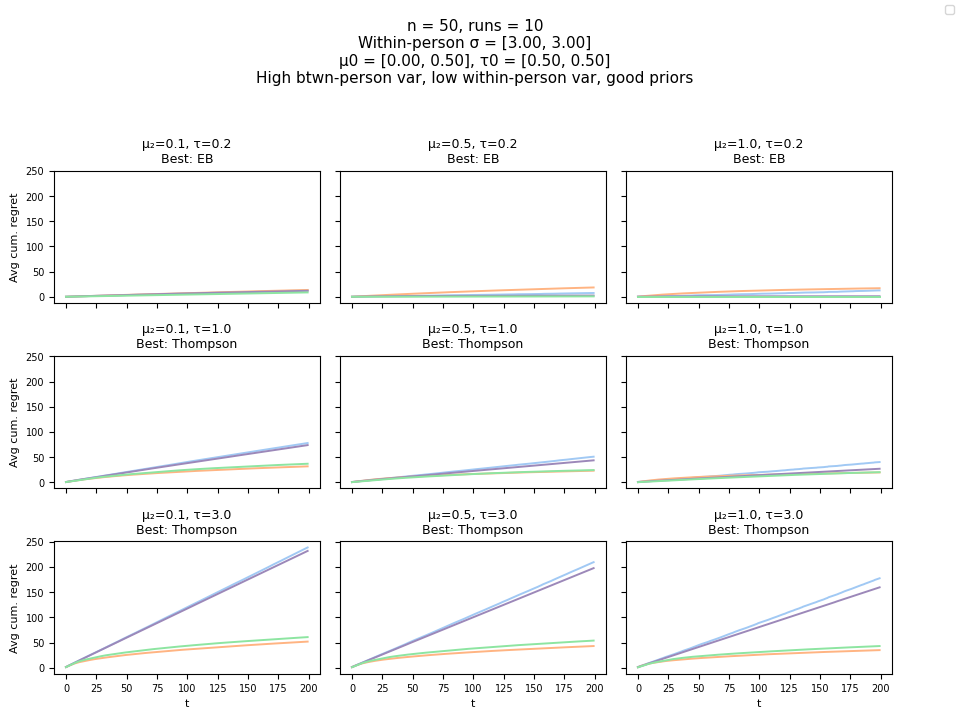

In [19]:
plot(
    ns=[50],
    mus=[0.1, 0.5, 1.0],
    taus=[0.2, 1.0, 3.0],      
    T=200,
    sigma_a=[3.0, 3.0],     
    n_runs=10,
    env_seed=0,
    eps=0.1,
    mu0=[0.0, 0.5],
    tau0=[0.5, 0.5],
    note="High btwn-person var, low within-person var, good priors"
)

- **Pooled** = light blue
- **Thompson** = soft orange
- **Pooled Thompson** = soft purple
- **EB** = light green

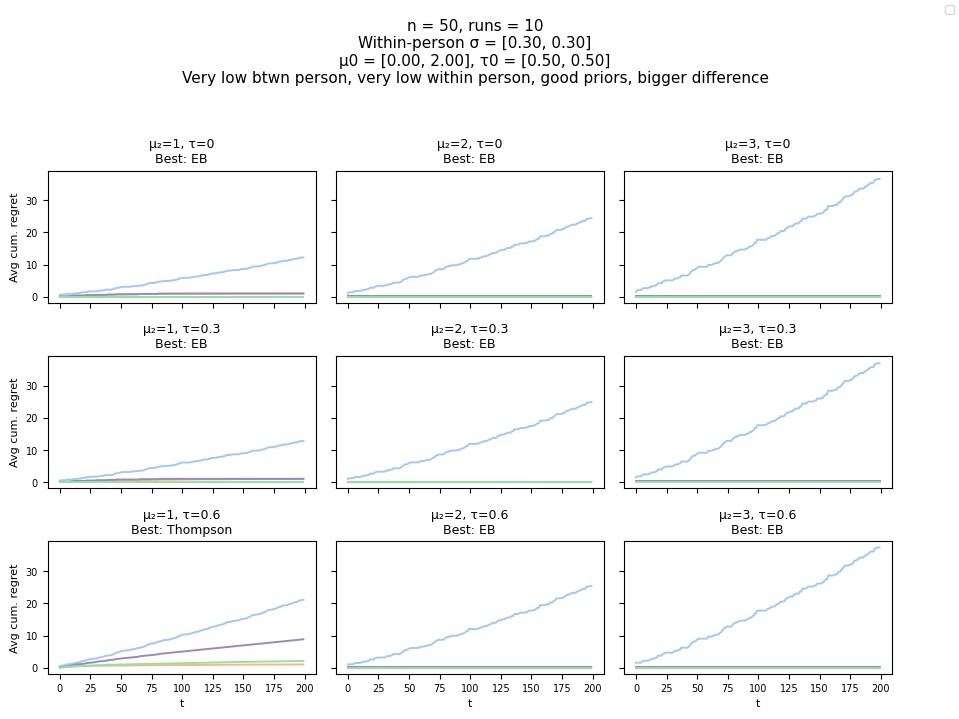

In [17]:
plot(
    ns=[50],
    mus=[1, 2, 3],
    taus=[0, 0.3, 0.6],      
    T=200,
    sigma_a=[0.3, 0.3],     
    n_runs=10,
    env_seed=0,
    eps=0.1,
    mu0=[0.0, 2],
    tau0=[0.5, 0.5],
    note="Very low btwn person, very low within person, good priors, bigger difference"
)

- **Pooled** = light blue
- **Thompson** = soft orange
- **Pooled Thompson** = soft purple
- **EB** = light green

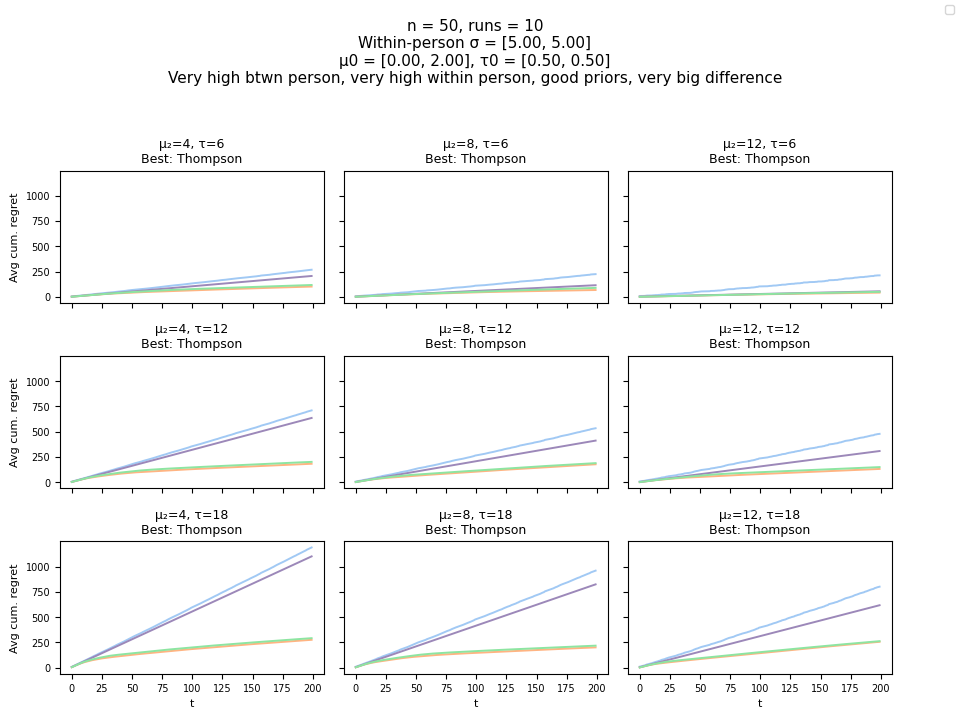

In [18]:
plot(
    ns=[50],
    mus=[4, 8, 12],
    taus=[6,12,18],      
    T=200,
    sigma_a=[5.0, 5.0],     
    n_runs=10,
    env_seed=0,
    eps=0.1,
    mu0=[0.0, 2],
    tau0=[0.5, 0.5],
    note="Very high btwn person, very high within person, good priors, very big difference"
)

- **Pooled** = light blue
- **Thompson** = soft orange
- **Pooled Thompson** = soft purple
- **EB** = light green

#### Trials — Varying Within Var

In [ ]:
plot2(
    ns=[50],
    taus=[0.2, 1.0, 3.0],
    sigmas=[0.5, 1.0, 3.0],   # within-person SD levels to compare
    T=200,
    mu_env=(0.0, 0.5),        # fixed means, no more mu grid
    n_runs=10,
    env_seed=0,
    eps=0.1,
    mu0=[0.0, 0.5],
    tau0=[0.5, 0.5],
    note="Varying within-person variance (σ); fixed means"
)